In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score, precision_score, recall_score, f1_score
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

In [ ]:
df = pd.read_csv("/content/Fraudulent Transactions Data.csv")
df

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.0,0.0,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.0,0.0,0.0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.0,1.0,0.0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.0,1.0,0.0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
219760,14,PAYMENT,591.50,C1443113739,104879.68,104288.18,M936090293,0.00,0.0,0.0,0.0
219761,14,PAYMENT,14839.24,C554257502,104288.18,89448.94,M1152875694,0.00,0.0,0.0,0.0
219762,14,CASH_IN,144258.67,C865880896,298512.00,442770.67,C351716642,891449.26,747190.6,0.0,0.0
219763,14,CASH_OUT,348453.47,C1483305396,11894.00,0.00,C466835398,373004.93,721458.4,0.0,0.0


In [ ]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,219765.000000,2.197650e+05,2.197650e+05,2.197640e+05,2.197640e+05,2.197640e+05,219764.000000,219764.0
mean,10.330407,1.808084e+05,8.825071e+05,9.003847e+05,9.497383e+05,1.189618e+06,0.000705,0.0
std,2.192156,3.254299e+05,2.794303e+06,2.831588e+06,2.369067e+06,2.633400e+06,0.026548,0.0
min,1.000000,3.000000e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.0
25%,9.000000,1.229706e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.0
50%,11.000000,7.083043e+04,1.952100e+04,0.000000e+00,5.525830e+04,1.464908e+05,0.000000,0.0
75%,12.000000,2.306170e+05,1.932596e+05,2.294439e+05,7.889001e+05,1.195410e+06,0.000000,0.0
max,14.000000,1.000000e+07,3.893942e+07,3.894623e+07,3.903958e+07,3.904248e+07,1.000000,0.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 219765 entries, 0 to 219764
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   step            219765 non-null  int64  
 1   type            219765 non-null  object 
 2   amount          219765 non-null  float64
 3   nameOrig        219765 non-null  object 
 4   oldbalanceOrg   219765 non-null  float64
 5   newbalanceOrig  219764 non-null  float64
 6   nameDest        219764 non-null  object 
 7   oldbalanceDest  219764 non-null  float64
 8   newbalanceDest  219764 non-null  float64
 9   isFraud         219764 non-null  float64
 10  isFlaggedFraud  219764 non-null  float64
dtypes: float64(7), int64(1), object(3)
memory usage: 18.4+ MB


In [ ]:
print("Missing values:\n", df.isnull().sum())

Missing values:
 step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    1
nameDest          1
oldbalanceDest    1
newbalanceDest    1
isFraud           1
isFlaggedFraud    1
dtype: int64


In [ ]:
df['oldbalanceDest'].fillna(df['oldbalanceDest'].median(), inplace=True)
df['newbalanceDest'].fillna(df['newbalanceDest'].median(), inplace=True)
df['isFraud'].fillna(0, inplace=True)  # Fraud should not be missing
df['isFlaggedFraud'].fillna(0, inplace=True)

<ipython-input-8-f67fe5fc661d>:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['oldbalanceDest'].fillna(df['oldbalanceDest'].median(), inplace=True)
<ipython-input-8-f67fe5fc661d>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, in

In [ ]:
print("Missing values after handling:\n", df.isnull().sum())


Missing values after handling:
 step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    1
nameDest          1
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64


In [ ]:
df = df.drop_duplicates()
df


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.000,0.0,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.000,0.0,0.0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.000,1.0,0.0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.000,1.0,0.0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.000,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
219760,14,PAYMENT,591.50,C1443113739,104879.68,104288.18,M936090293,0.00,0.000,0.0,0.0
219761,14,PAYMENT,14839.24,C554257502,104288.18,89448.94,M1152875694,0.00,0.000,0.0,0.0
219762,14,CASH_IN,144258.67,C865880896,298512.00,442770.67,C351716642,891449.26,747190.600,0.0,0.0
219763,14,CASH_OUT,348453.47,C1483305396,11894.00,0.00,C466835398,373004.93,721458.400,0.0,0.0


<ipython-input-11-b796a0f42990>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['isFraud'], palette='coolwarm')


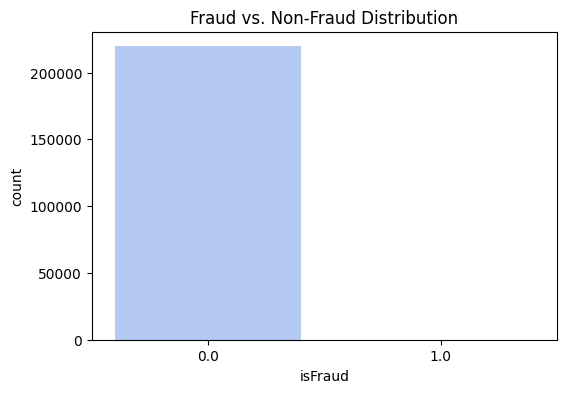

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x=df['isFraud'], palette='coolwarm')
plt.title("Fraud vs. Non-Fraud Distribution")
plt.show()

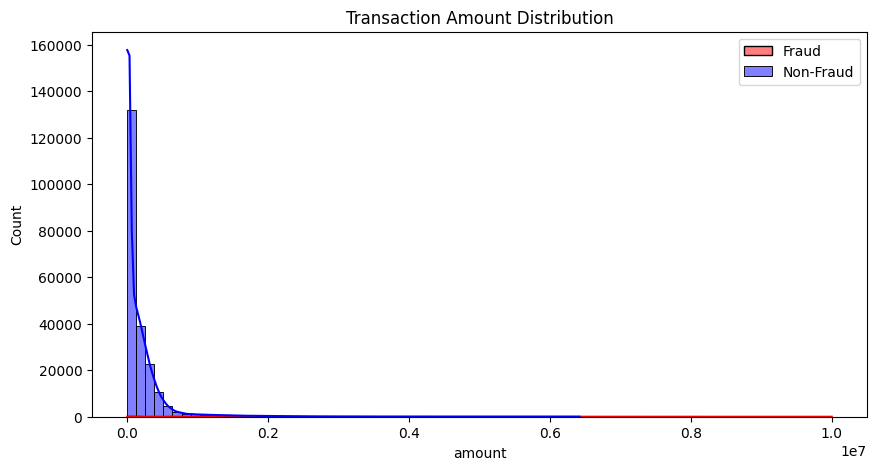

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(df[df['isFraud'] == 1]['amount'], bins=50, color='red', label='Fraud', kde=True)
sns.histplot(df[df['isFraud'] == 0]['amount'], bins=50, color='blue', label='Non-Fraud', kde=True)
plt.legend()
plt.title("Transaction Amount Distribution")
plt.show()

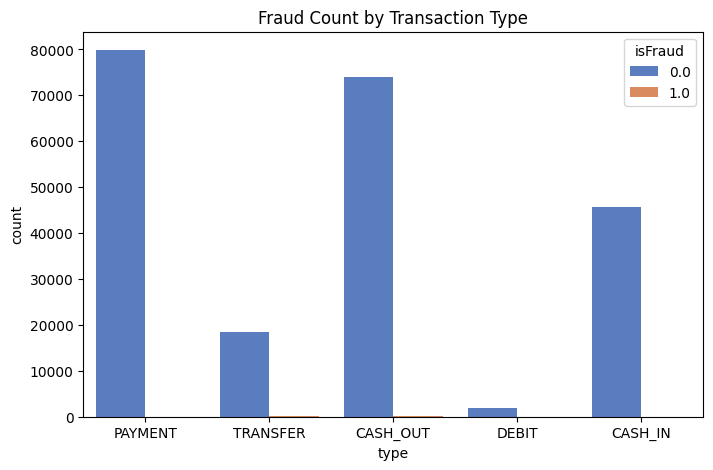

In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(x='type', hue='isFraud', data=df, palette='muted')
plt.title("Fraud Count by Transaction Type")
plt.show()

In [ ]:
df = pd.get_dummies(df, columns=['type'], drop_first=True)

In [ ]:
df['isFraud'] = df['isFraud'].fillna(0).astype(int)

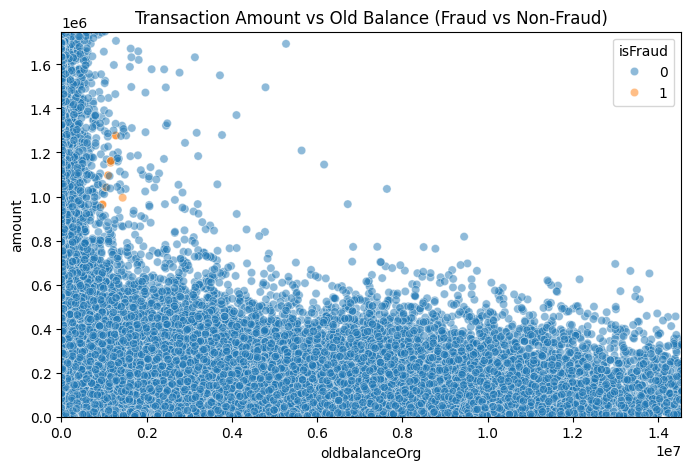

In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=df['oldbalanceOrg'], y=df['amount'], hue=df['isFraud'], alpha=0.5)
plt.xlim(0, df['oldbalanceOrg'].quantile(0.99))
plt.ylim(0, df['amount'].quantile(0.99))
plt.title("Transaction Amount vs Old Balance (Fraud vs Non-Fraud)")
plt.show()

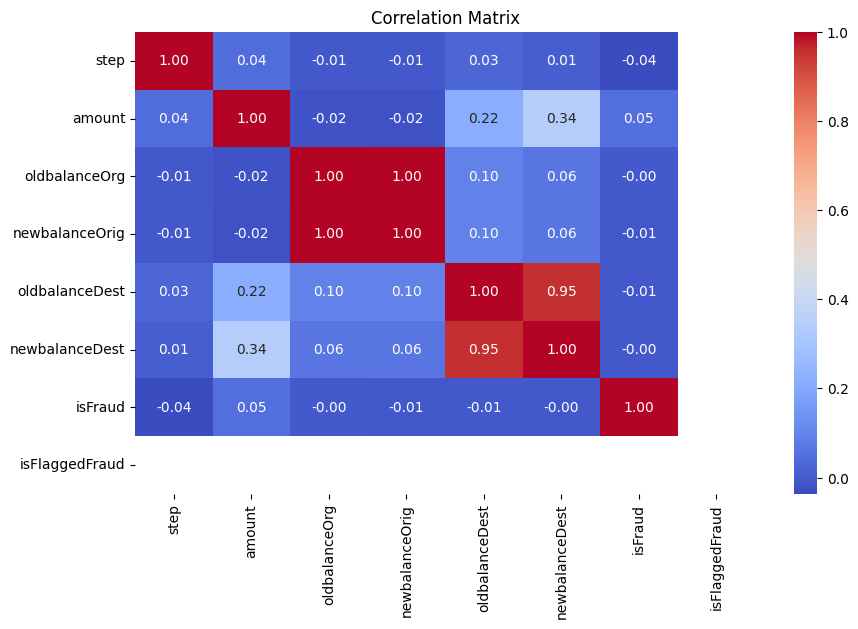

In [ ]:
plt.figure(figsize=(10, 6))
numeric_df = df.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix")
plt.show()

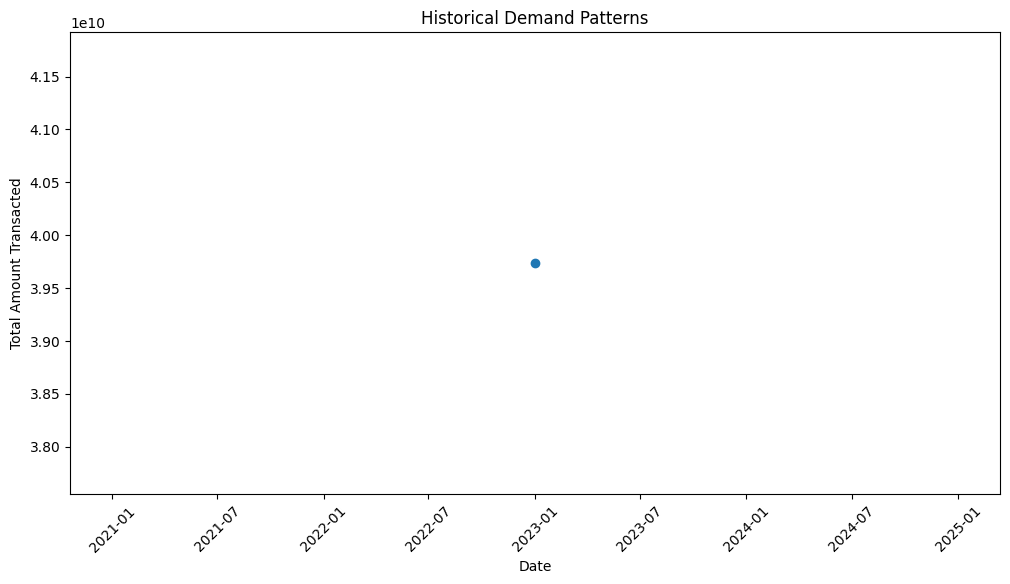

In [ ]:
df['step'] = pd.to_datetime(df['step'], unit='h', origin=pd.Timestamp('2023-01-01'))
demand_trends = df.groupby(df['step'].dt.date)['amount'].sum()
plt.figure(figsize=(12, 6))
plt.plot(demand_trends, marker='o', linestyle='-')
plt.xticks(rotation=45)
plt.title("Historical Demand Patterns")
plt.xlabel("Date")
plt.ylabel("Total Amount Transacted")
plt.show()

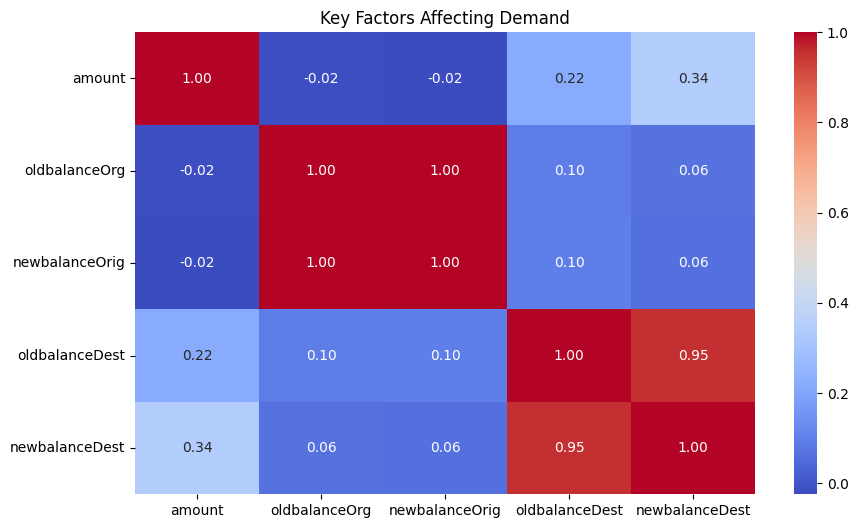

In [ ]:
correlation_demand = df[['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']].corr()
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_demand, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Key Factors Affecting Demand")
plt.show()

In [ ]:
df['balance_change'] = df['oldbalanceOrg'] - df['newbalanceOrig']
df['transaction_ratio'] = df['amount'] / (df['oldbalanceOrg'] + 1)
df['transaction_gap'] = df.groupby('nameOrig')['step'].diff().fillna(0)
df['balance_change_ratio'] = (df['oldbalanceOrg'] - df['newbalanceOrig']) / (df['oldbalanceOrg'] + 1)
df['recipient_balance_change'] = (df['oldbalanceDest'] - df['newbalanceDest']) / (df['oldbalanceDest'] + 1)
df['large_transaction_flag'] = np.where(df['amount'] > 200000, 1, 0)
df['zero_balance_after_txn'] = np.where(df['newbalanceOrig'] == 0, 1, 0)
df


,step,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,...,type_DEBIT,type_PAYMENT,type_TRANSFER,balance_change,transaction_ratio,transaction_gap,balance_change_ratio,recipient_balance_change,large_transaction_flag,zero_balance_after_txn
0,2023-01-01 01:00:00,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.000,0,0.0,...,False,True,False,9839.64,0.057834,0,0.057834,0.000000,0,0
1,2023-01-01 01:00:00,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.000,0,0.0,...,False,True,False,1864.28,0.087731,0,0.087731,0.000000,0,0
2,2023-01-01 01:00:00,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.000,1,0.0,...,False,False,True,181.00,0.994505,0,0.994505,0.000000,0,1
3,2023-01-01 01:00:00,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.000,1,0.0,...,False,False,False,181.00,0.994505,0,0.994505,0.999953,0,1
4,2023-01-01 01:00:00,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.000,0,0.0,...,False,True,False,11668.14,0.280788,0,0.280788,0.000000,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
219760,2023-01-01 14:00:00,591.50,C1443113739,104879.68,104288.18,M936090293,0.00,0.000,0,0.0,...,False,True,False,591.50,0.005640,0,0.005640,0.000000,0,0
219761,2023-01-01 14:00:00,14839.24,C554257502,104288.18,89448.94,M1152875694,0.00,0.000,0,0.0,...,False,True,False,14839.24,0.142289,0,0.142289,0.000000,0,0
219762,2023-01-01 14:00:00,144258.67,C865880896,298512.00,442770.67,C351716642,891449.26,747190.600,0,0.0,...,False,False,False,-144258.67,0.483258,0,-0.483258,0.161825,0,0
219763,2023-01-01 14:00:00,348453.47,C1483305396,11894.00,0.00,C466835398,373004.93,721458.400,0,0.0,...,False,False,False,11894.00,29.294113,0,0.999916,-0.934177,1,1


In [ ]:
def detect_fraud(row):
    if row['type_TRANSFER'] == 1 and row['large_transaction_flag'] == 1:
        return 1
    if row['type_CASH_OUT'] == 1 and row['zero_balance_after_txn'] == 1:
        return 1
    return 0

df['fraud_flag'] = df.apply(detect_fraud, axis=1)

In [ ]:
df['avg_transaction_amount'] = df.groupby('nameOrig')['amount'].transform('mean')
df['transaction_frequency'] = df.groupby('nameOrig')['step'].transform('count')
df['high_frequency_flag'] = np.where(df['transaction_frequency'] > df['transaction_frequency'].quantile(0.95), 1, 0)

In [ ]:
df['suspicious_transfer'] = np.where((df['type_TRANSFER'] == 1) &
                                     (df['amount'] > df['oldbalanceOrg'] * 0.8), 1, 0)

In [ ]:
df['final_fraud_flag'] = np.where((df['isFraud'] == 1) |
                                  (df['suspicious_transfer'] == 1), True, False)

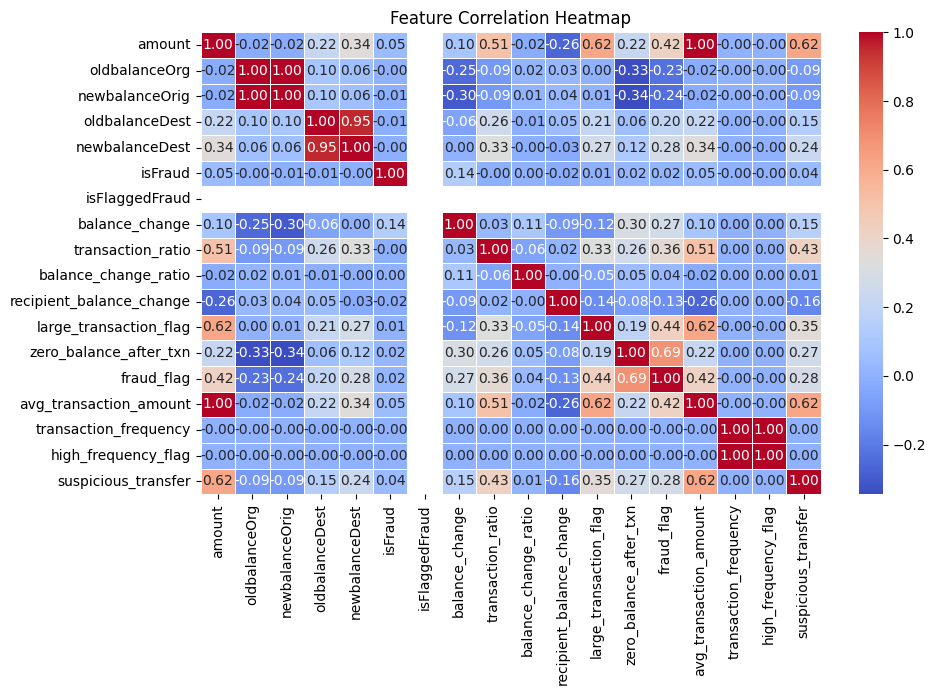

In [ ]:
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

In [ ]:
features = ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'balance_change', 'transaction_ratio'] + list(df.columns[df.columns.str.startswith('type_')])
X = df[features]
y = df['isFraud']

In [ ]:
print("Fraud class distribution before resampling:\n", y.value_counts())

Fraud class distribution before resampling:
 isFraud
0    219610
1       155
Name: count, dtype: int64


In [ ]:
!pip install scikit-learn
import pandas as pd
from sklearn.impute import SimpleImputer

# Create an imputer object
imputer = SimpleImputer(strategy='median')  # Replace 'median' with 'mean' or other strategies if needed

# Fit the imputer to your training data and transform
X_resampled = imputer.fit_transform(X)

# Apply SMOTE after imputation
smote = SMOTE(sampling_strategy=0.3, random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_resampled, y)

In [ ]:
print("Fraud class distribution after resampling:\n", pd.Series(y_resampled).value_counts())

Fraud class distribution after resampling:
 isFraud
0    219610
1     65883
Name: count, dtype: int64


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled)

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5]
}

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.neural_network import MLPClassifier

models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, scale_pos_weight=10, random_state=42),
    "LightGBM": LGBMClassifier(n_estimators=100, random_state=42),
    "Neural Network": MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=300, random_state=42)
}

In [ ]:
results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else y_pred


    acc = accuracy_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)

    results.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": report.get('1', {}).get('precision', np.nan),
        "Recall": report.get('1', {}).get('recall', np.nan),
        "F1-Score": report.get('1', {}).get('f1-score', np.nan),
        "AUC-ROC": auc
    })

results_df = pd.DataFrame(results)
print(results_df)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Number of positive: 52706, number of negative: 175688
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.017954 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2301
[LightGBM] [Info] Number of data points in the train set: 228394, number of used features: 11
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.230768 -> initscore=-1.203980
[LightGBM] [Info] Start training from score -1.203980


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


                 Model  Accuracy  Precision    Recall  F1-Score   AUC-ROC
0  Logistic Regression  0.961891   0.917432  0.917432  0.917432  0.985178
1        Random Forest  0.999580   0.998862  0.999317  0.999090  0.999975
2              XGBoost  0.998599   0.994040  0.999924  0.996973  0.999964
3             LightGBM  0.999685   0.998938  0.999696  0.999317  0.999998
4       Neural Network  0.994431   0.979420  0.996813  0.988040  0.999750


/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


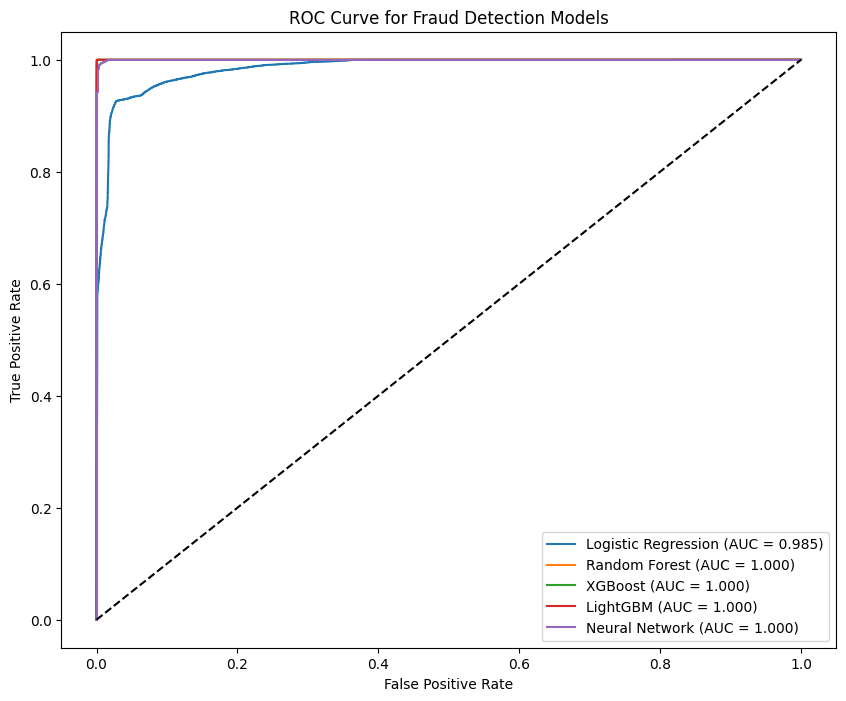

In [ ]:
plt.figure(figsize=(10, 8))

from sklearn.metrics import roc_curve

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1] if hasattr(model, "predict_proba") else model.predict(X_test)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc_score(y_test, y_prob):.3f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Fraud Detection Models")
plt.legend()
plt.show()

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


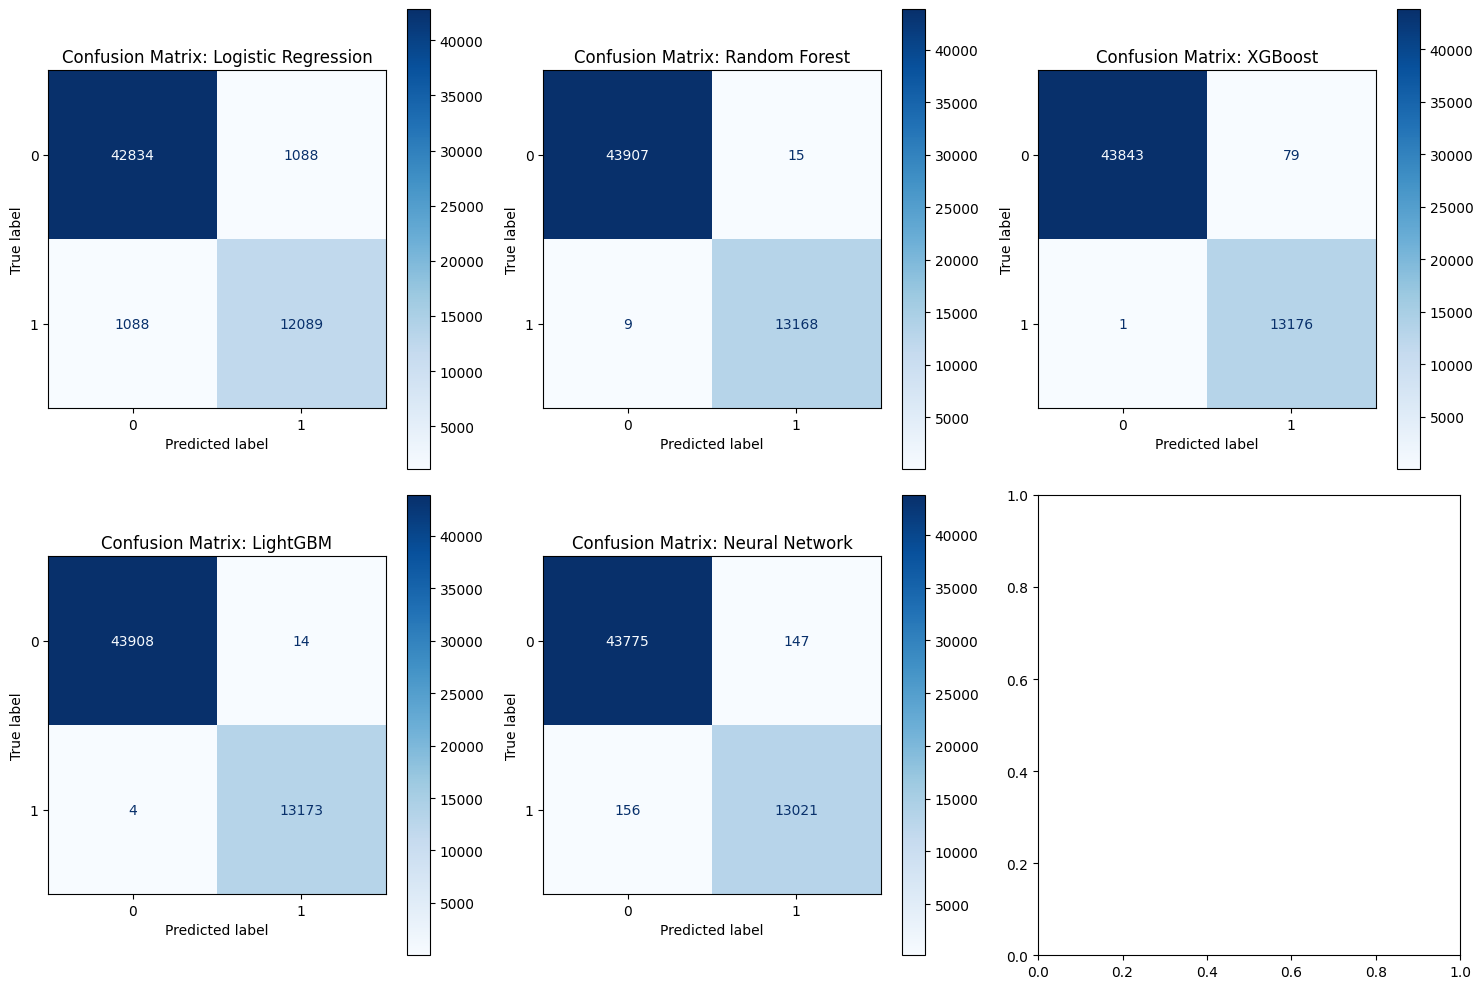

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot(ax=axes[idx], cmap="Blues", values_format="d")
    axes[idx].set_title(f"Confusion Matrix: {name}")

plt.tight_layout()
plt.show()


In [ ]:
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
grid = GridSearchCV(xgb, param_grid, cv=5, scoring='roc_auc')
grid.fit(X_train, y_train)

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [08:44:49] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [08:44:55] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [08:44:56] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [08:44:58] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [08:44:59] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_e

GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=None,
                                     learning_rate=...
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None,
                                     random_state=42, ...),
             param_grid={'learning_rate': [0.01, 0.1], 'max_depth': [3, 5],
                         'n_estimators': [100, 200]},
             scoring='roc_auc')

In [ ]:
best_model = grid.best_estimator_
print("Best Hyperparameters:", grid.best_params_)

Best Hyperparameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}


In [ ]:
cv_scores = cross_val_score(best_model, X_train, y_train, cv=5, scoring='roc_auc')
print("Cross-Validation AUC Scores:", cv_scores)
print("Mean CV AUC:", np.mean(cv_scores))

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [08:47:17] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [08:47:28] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [08:47:30] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [08:47:33] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [08:47:39] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_e

Cross-Validation AUC Scores: [0.99995753 0.99997895 0.99997492 0.99998038 0.99995495]
Mean CV AUC: 0.9999693476903886


In [ ]:
best_model.fit(X_train, y_train)


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [08:47:53] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

In [ ]:
import joblib

# Assuming 'best_model' from previous cells is the intended XGBoost model
joblib.dump(best_model, "xgboost_model.pkl")

['xgboost_model.pkl']

In [ ]:
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

In [ ]:
X_train_lstm = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_test_lstm = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dropout, Dense

lstm_model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(1, X_train.shape[1])),
    Dropout(0.2),
    LSTM(50),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
lstm_model.fit(X_train_lstm, y_train, epochs=10, batch_size=32, validation_data=(X_test_lstm, y_test))

Epoch 1/10
7138/7138 ━━━━━━━━━━━━━━━━━━━━ 51s 6ms/step - accuracy: 0.9349 - loss: 0.1684 - val_accuracy: 0.9695 - val_loss: 0.0788
Epoch 2/10
7138/7138 ━━━━━━━━━━━━━━━━━━━━ 37s 5ms/step - accuracy: 0.9703 - loss: 0.0807 - val_accuracy: 0.9778 - val_loss: 0.0594
Epoch 3/10
7138/7138 ━━━━━━━━━━━━━━━━━━━━ 34s 5ms/step - accuracy: 0.9751 - loss: 0.0697 - val_accuracy: 0.9826 - val_loss: 0.0545
Epoch 4/10
7138/7138 ━━━━━━━━━━━━━━━━━━━━ 36s 5ms/step - accuracy: 0.9772 - loss: 0.0633 - val_accuracy: 0.9817 - val_loss: 0.0498
Epoch 5/10
7138/7138 ━━━━━━━━━━━━━━━━━━━━ 36s 5ms/step - accuracy: 0.9800 - loss: 0.0575 - val_accuracy: 0.9870 - val_loss: 0.0482
Epoch 6/10
7138/7138 ━━━━━━━━━━━━━━━━━━━━ 35s 5ms/step - accuracy: 0.9810 - loss: 0.0535 - val_accuracy: 0.9864 - val_loss: 0.0431
Epoch 7/10
7138/7138 ━━━━━━━━━━━━━━━━━━━━ 33s 5ms/step - accuracy: 0.9827 - loss: 0.0487 - val_accuracy: 0.9871 - val_loss: 0.0357
Epoch 8/10
7138/7138 ━━━━━━━━━━━━━━━━━━━━ 36s 5ms/step - accuracy: 0.9831 - loss: 0

In [ ]:
lstm_model.save("lstm_model.h5")

AttributeError: 'MLPClassifier' object has no attribute 'save'

In [ ]:
y_prob_lstm = lstm_model.predict(X_test_lstm).flatten()
y_pred_lstm = (y_prob_lstm > 0.5).astype(int)

1785/1785 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step


In [ ]:
acc_lstm = accuracy_score(y_test, y_pred_lstm)
auc_lstm = roc_auc_score(y_test, y_prob_lstm)
report_lstm = classification_report(y_test, y_pred_lstm, output_dict=True)

In [ ]:
results_df = pd.concat([results_df, pd.DataFrame([{
    "Model": "LSTM",
    "Accuracy": acc_lstm,
    "Precision": report_lstm.get('1', {}).get('precision', np.nan),
    "Recall": report_lstm.get('1', {}).get('recall', np.nan),
    "F1-Score": report_lstm.get('1', {}).get('f1-score', np.nan),
    "AUC-ROC": auc_lstm
}])], ignore_index=True)

In [ ]:
print(results_df)

                 Model  Accuracy  Precision    Recall  F1-Score   AUC-ROC
0  Logistic Regression  0.961891   0.917432  0.917432  0.917432  0.985178
1        Random Forest  0.999580   0.998862  0.999317  0.999090  0.999975
2              XGBoost  0.998599   0.994040  0.999924  0.996973  0.999964
3             LightGBM  0.999685   0.998938  0.999696  0.999317  0.999998
4       Neural Network  0.994431   0.979420  0.996813  0.988040  0.999750
5                 LSTM  0.986515   0.954569  0.988617  0.971294  0.999188


In [ ]:
print("\nPerformance Metrics:")

# Assuming you want to print the LSTM's performance, as this cell follows LSTM evaluation
acc = acc_lstm
auc = auc_lstm
precision = report_lstm.get('1', {}).get('precision', np.nan)
recall = report_lstm.get('1', {}).get('recall', np.nan)
f1 = report_lstm.get('1', {}).get('f1-score', np.nan)


print(f"Accuracy: {acc:.4f}")
print(f"AUC-ROC: {auc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")


Performance Metrics:
Accuracy: 0.9865
AUC-ROC: 0.9992
Precision: 0.9546
Recall: 0.9886
F1-Score: 0.9713


In [ ]:
train_acc_xgb = accuracy_score(y_train, models["XGBoost"].predict(X_train))
test_acc_xgb = accuracy_score(y_test, models["XGBoost"].predict(X_test))

print(f"XGBoost - Train Accuracy: {train_acc_xgb:.4f}, Test Accuracy: {test_acc_xgb:.4f}")


XGBoost - Train Accuracy: 0.9986, Test Accuracy: 0.9986


In [ ]:
train_prob_xgb = models["XGBoost"].predict_proba(X_train)[:, 1]
test_prob_xgb = models["XGBoost"].predict_proba(X_test)[:, 1]

train_auc_xgb = roc_auc_score(y_train, train_prob_xgb)
test_auc_xgb = roc_auc_score(y_test, test_prob_xgb)

print(f"XGBoost - Train AUC: {train_auc_xgb:.4f}, Test AUC: {test_auc_xgb:.4f}")



XGBoost - Train AUC: 1.0000, Test AUC: 1.0000


In [ ]:
train_pred_lstm = lstm_model.predict(X_train_lstm).flatten()
test_pred_lstm = lstm_model.predict(X_test_lstm).flatten()

train_acc_lstm = accuracy_score(y_train, (train_pred_lstm > 0.5).astype(int))
test_acc_lstm = accuracy_score(y_test, (test_pred_lstm > 0.5).astype(int))

print(f"LSTM - Train Accuracy: {train_acc_lstm:.4f}, Test Accuracy: {test_acc_lstm:.4f}")


7138/7138 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step
1785/1785 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step
LSTM - Train Accuracy: 0.9852, Test Accuracy: 0.9865


In [ ]:
!pip install streamlit
!pip install streamlit-ngrok
!pip install joblib


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 24.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 28.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 4.4 MB/s eta 0:00:00
ERROR: Could not find a version that satisfies the requirement streamlit-ngrok (from versions: none)
ERROR: No matching distribution found for streamlit-ngrok


In [ ]:
%%writefile app.py
import streamlit as st
import joblib
import numpy as np
import tensorflow as tf

# Load trained models
xgb_model = joblib.load("/content/xgboost_model.pkl")
lstm_model = tf.keras.models.load_model("/content/lstm_model.h5")

# Define Streamlit app
st.title("Fraud Detection System")

st.write("Enter transaction details to predict fraud.")

# Input fields for transaction details
amount = st.number_input("Transaction Amount", min_value=0.0, step=0.01)
oldbalanceOrg = st.number_input("Old Balance (Origin)", min_value=0.0, step=0.01)
newbalanceOrig = st.number_input("New Balance (Origin)", min_value=0.0, step=0.01)
oldbalanceDest = st.number_input("Old Balance (Destination)", min_value=0.0, step=0.01)
newbalanceDest = st.number_input("New Balance (Destination)", min_value=0.0, step=0.01)

# Feature Engineering (Adding derived features)
balance_change = oldbalanceOrg - newbalanceOrig  # Change in origin account balance
transaction_ratio = amount / (oldbalanceOrg + 1)  # Transaction ratio relative to origin balance
transaction_balance_ratio = amount / (oldbalanceOrg + newbalanceDest + 1e-6)  # Add a small value to the denominator to prevent ZeroDivisionError
balance_diff = oldbalanceOrg - oldbalanceDest  # Balance difference between origin and destination accounts
dest_balance_diff = newbalanceDest - oldbalanceDest  # Change in destination account balance
amount_to_balance_ratio = amount / (oldbalanceOrg + 1)  # Transaction amount vs origin balance


features = np.array([[amount, oldbalanceOrg, newbalanceOrig, oldbalanceDest, newbalanceDest,
                      balance_change, transaction_ratio, transaction_balance_ratio,
                      balance_diff, dest_balance_diff, amount_to_balance_ratio]])

if st.button("Predict Fraud"):
    xgb_prediction = xgb_model.predict(features)[0]
    xgb_prob = xgb_model.predict_proba(features)[0][1]

    lstm_input = features.reshape((1, 1, features.shape[1]))
    lstm_prediction = lstm_model.predict(lstm_input)[0][0]

    # Display Results
    st.write("### XGBoost Prediction:")
    st.write(f"Fraud Probability: {xgb_prob:.4f}")
    st.write("Fraud Detected" if xgb_prediction == 1 else "Not Fraudulent")

    st.write("### LSTM Prediction:")
    st.write(f"Fraud Probability: {lstm_prediction:.4f}")
    st.write("Fraud Detected" if lstm_prediction > 0.5 else "Not Fraudulent")


Writing app.py


In [ ]:
!streamlit run app.py